In [1]:
%cd ..

D:\Projects\GitHub\introduction-to-sensor-fusion\software


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from utils.loader import load
from utils.orientation import pitch_from_quat, pitch_from_accel

In [3]:
rec = load("../recordings/pitch_slow")
print(rec.summary())

pitch_slow  (BNO_GRV, 30.2 s)
  acc     3522 samples   117.3 Hz
  gyro    2994 samples    99.8 Hz
  mag     1909 samples    63.7 Hz
  ref     2994 samples    99.8 Hz


In [4]:
# Timestamps and raw arrays
t_acc = rec.acc.t                      # seconds
a = rec.acc.xyz("a")                   # (N, 3) -- ax, ay, az
g = rec.gyro.xyz("g")                  # (N, 3) -- gx, gy, gz
q = np.column_stack([rec.ref.data[c] for c in ("qw", "qx", "qy", "qz")])

In [5]:
pitch_ref = pitch_from_quat(q)
pitch_acc = pitch_from_accel(a)

# Sanity check on the flat portion at the start of the recording.
print(f"first 2 s -- ref: {pitch_ref[rec.ref.t < 2].mean():+.2f} deg, "
      f"accel: {pitch_acc[rec.acc.t < 2].mean():+.2f} deg")

first 2 s -- ref: +1.74 deg, accel: +1.49 deg


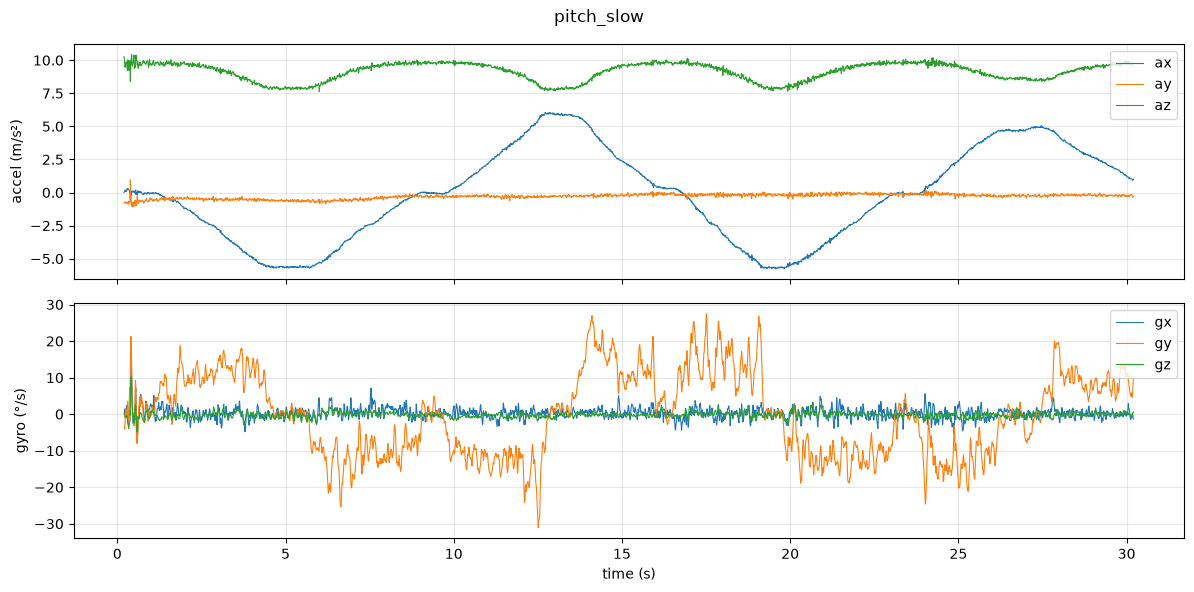

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for i, name in enumerate(["ax", "ay", "az"]):
    ax[0].plot(rec.acc.t, a[:, i], lw=0.8, label=name)
ax[0].set_ylabel("accel (m/s²)")
ax[0].legend(loc="upper right")
ax[0].grid(alpha=0.3)

for i, name in enumerate(["gx", "gy", "gz"]):
    ax[1].plot(rec.gyro.t, np.degrees(g[:, i]), lw=0.8, label=name)
ax[1].set_ylabel("gyro (°/s)")
ax[1].set_xlabel("time (s)")
ax[1].legend(loc="upper right")
ax[1].grid(alpha=0.3)

fig.suptitle(rec.path.name)
plt.tight_layout()

Text(0.5, 1.0, 'Naive pitch estimates — pitch_slow')

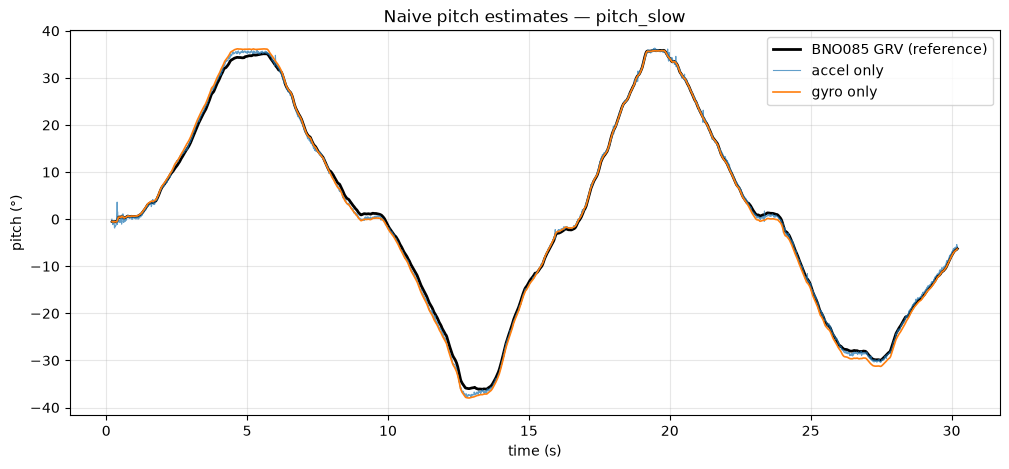

In [7]:
# Integrate the gyro using real timestamps, starting from the reference's
# initial pitch so the two traces begin together.
gy = g[:, 1]
dt = np.diff(rec.gyro.t)
pitch_gyro = np.concatenate([[pitch_ref[0]],
                             pitch_ref[0] + np.degrees(np.cumsum(gy[:-1] * dt))])

plt.figure(figsize=(12, 5))
plt.plot(rec.ref.t,  pitch_ref,  'k',  lw=2,   label="BNO085 GRV (reference)")
plt.plot(rec.acc.t,  pitch_acc,  'C0', lw=0.8, alpha=0.7, label="accel only")
plt.plot(rec.gyro.t, pitch_gyro, 'C1', lw=1.2, label="gyro only")
plt.ylabel("pitch (°)")
plt.xlabel("time (s)")
plt.legend()
plt.grid(alpha=0.3)
plt.title(f"Naive pitch estimates — {rec.path.name}")

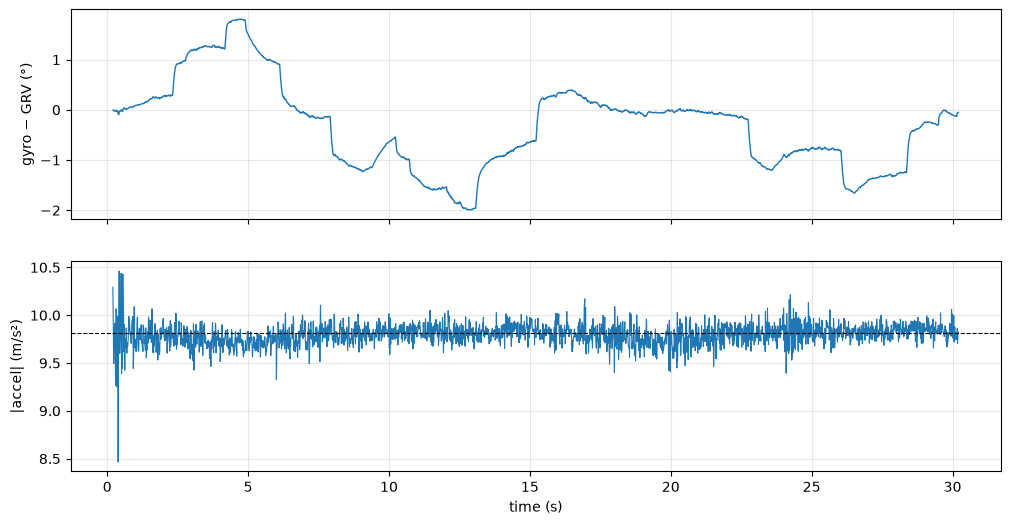

In [8]:
# Interpolate GRV onto the gyro timestamps to difference them
ref_on_gyro = np.interp(rec.gyro.t, rec.ref.t, pitch_ref)
err = pitch_gyro - ref_on_gyro

accel_mag = np.linalg.norm(a, axis=1)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(rec.gyro.t, err, lw=1)
ax[0].set_ylabel("gyro − GRV (°)")
ax[0].grid(alpha=0.3)
ax[1].plot(rec.acc.t, accel_mag, lw=0.8)
ax[1].axhline(9.81, color='k', ls='--', lw=0.8)
ax[1].set_ylabel("|accel| (m/s²)")
ax[1].set_xlabel("time (s)")
ax[1].grid(alpha=0.3)

In [12]:
static = rec.gyro.t > 5          # skip the initial tilt
bias = np.degrees(g[static, 1].mean())
print(f"mean gy during hold: {bias:+.4f} °/s  ->  {bias*180:+.1f}° over 180 s")

mean gy during hold: -0.0344 °/s  ->  -6.2° over 180 s


In [13]:
def complementary_simple(pitch_acc, gyro_y, dt, alpha):
    """
    One-axis complementary filter, uniform dt.

    pitch = alpha * (previous pitch + gyro integration) + (1 - alpha) * accel

    alpha near 1 trusts the gyro (fast, drifts); alpha near 0 trusts the
    accelerometer (stable, noisy and fooled by linear acceleration).
    """
    pitch = np.zeros(len(pitch_acc))
    pitch[0] = pitch_acc[0]

    for i in range(1, len(pitch)):
        predicted = pitch[i-1] + np.degrees(gyro_y[i]) * dt
        pitch[i] = alpha * predicted + (1 - alpha) * pitch_acc[i]

    return pitch

In [14]:
"""
complementary.py

One-axis complementary filter, blending gyro integration with the
accelerometer's tilt estimate.
"""

import numpy as np


class ComplementaryFilter:
    """
    Event-driven complementary filter for a single axis.

    Call predict() when a gyro sample arrives and correct() when an
    accelerometer sample arrives. This mirrors how the filter runs on
    hardware, where the two sensors report independently.
    """

    def __init__(self, alpha, pitch0=0.0):
        self.alpha = alpha
        self.pitch = pitch0
        self.t_last = None

    def predict(self, t, gyro_rate_deg):
        """Integrate the gyro forward to time t."""
        if self.t_last is not None:
            self.pitch += gyro_rate_deg * (t - self.t_last)
        self.t_last = t
        return self.pitch

    def correct(self, pitch_acc):
        """Pull the estimate toward the accelerometer's measurement."""
        self.pitch = self.alpha * self.pitch + (1 - self.alpha) * pitch_acc
        return self.pitch

    @property
    def tau(self):
        """
        Crossover time constant in seconds, at 100 Hz.

        Motion faster than this is tracked by the gyro; slower drift is
        corrected by the accelerometer.
        """
        dt = 0.01
        return self.alpha * dt / (1 - self.alpha)


def run(rec, alpha, gyro_axis=1, pitch0=None):
    """
    Run the filter over a recording, merging the two streams by timestamp.

    Returns (t, pitch) sampled at every gyro and accel event.
    """
    from utils.orientation import pitch_from_accel

    a = rec.acc.xyz("a")
    g = rec.gyro.xyz("g")
    pitch_acc = pitch_from_accel(a)
    gyro_deg = np.degrees(g[:, gyro_axis])

    if pitch0 is None:
        pitch0 = pitch_acc[0]
    f = ComplementaryFilter(alpha, pitch0)

    # Interleave the two streams in timestamp order.
    events = sorted(
        [(t, "g", v) for t, v in zip(rec.gyro.t, gyro_deg)] +
        [(t, "a", v) for t, v in zip(rec.acc.t, pitch_acc)]
    )

    t_out, pitch_out = [], []
    for t, kind, value in events:
        if kind == "g":
            f.predict(t, value)
        else:
            f.correct(value)
        t_out.append(t)
        pitch_out.append(f.pitch)

    return np.array(t_out), np.array(pitch_out)

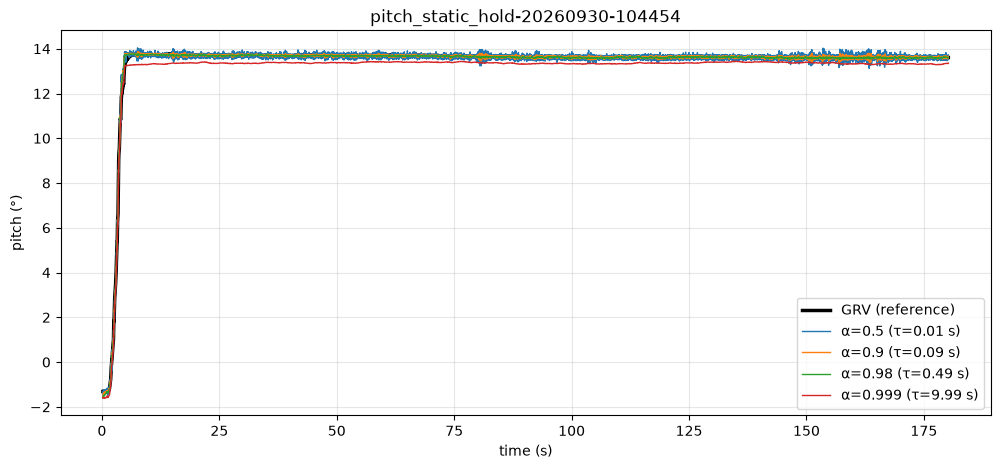

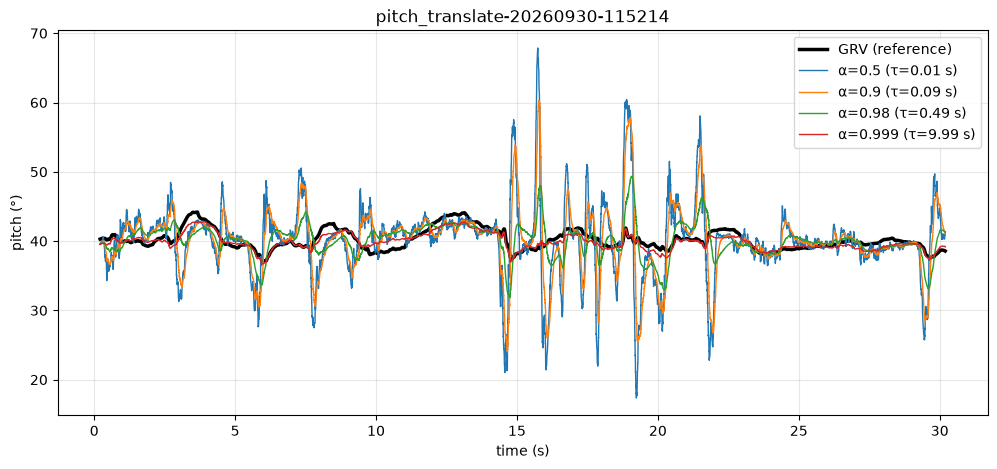

In [16]:
alphas = [0.5, 0.9, 0.98, 0.999]

for name in ["pitch_static_hold-20260930-104454", "pitch_translate-20260930-115214"]:
    rec = load(f"../recordings/{name}")
    q = np.column_stack([rec.ref.data[c] for c in ("qw", "qx", "qy", "qz")])
    pitch_ref = pitch_from_quat(q)

    plt.figure(figsize=(12, 5))
    plt.plot(rec.ref.t, pitch_ref, 'k', lw=2.5, label="GRV (reference)")
    for alpha in alphas:
        t, pitch = run(rec, alpha)
        tau = ComplementaryFilter(alpha).tau
        plt.plot(t, pitch, lw=1, label=f"α={alpha} (τ={tau:.2f} s)")
    plt.ylabel("pitch (°)")
    plt.xlabel("time (s)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.title(name)